<a href="https://colab.research.google.com/github/Dana69h/RESEARCH/blob/main/Research_Model_CART.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# Standard libraries
import os

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Model selection and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Scikit-learn: Decision Tree specific modules
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from sklearn.tree import export_graphviz
from sklearn.tree import _tree

# Visualization of Decision Trees
import graphviz
from graphviz import Digraph

# Scikit-learn: Model evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
# loads and concatenates file csv untuk pandas dataframes

path_ipm = '/content/drive/MyDrive/Dataset/IPM'
df_ipm = []

for year in range (2020, 2025):
  temp = pd.read_csv(f'{path_ipm}/{year}.csv')
  df_ipm.append(temp)

df_ipm = pd.concat(df_ipm, ignore_index=True)

path_pdrb = '/content/drive/MyDrive/Dataset/PDRB PERKAPITA'
df_pdrb = []

for year in range (2020, 2025):
  temp = pd.read_csv(f'{path_pdrb}/{year}.csv')
  df_pdrb.append(temp)

df_pdrb = pd.concat(df_pdrb, ignore_index=True)

path_pengper = '/content/drive/MyDrive/Dataset/PENGELUARAN PERKAPITA'
df_pengper = []

for year in range (2020, 2025):
  temp = pd.read_csv(f'{path_pengper}/{year}.csv')
  df_pengper.append(temp)

df_pengper = pd.concat(df_pengper, ignore_index=True)

path_perpm = '/content/drive/MyDrive/Dataset/PERSENTASE PENDUDUK MISKIN'
df_perpm = []

for year in range (2020, 2025):
  temp = pd.read_csv(f'{path_perpm}/{year}.csv')
  df_perpm.append(temp)

df_perpm = pd.concat(df_perpm, ignore_index=True)

path_rels = '/content/drive/MyDrive/Dataset/RERATA LAMA SEKOLAH'
df_rels = []

for year in range (2020, 2025):
  temp = pd.read_csv(f'{path_rels}/{year}.csv')
  df_rels.append(temp)

df_rels = pd.concat(df_rels, ignore_index=True)

path_tpak = '/content/drive/MyDrive/Dataset/TPAK'
df_tpak = []

for year in range (2020, 2025):
  temp = pd.read_csv(f'{path_tpak}/{year}.csv')
  df_tpak.append(temp)

df_tpak = pd.concat(df_tpak, ignore_index=True)

path_tpt = '/content/drive/MyDrive/Dataset/TPT'
df_tpt = []

for year in range (2020, 2025):
  temp = pd.read_csv(f'{path_tpt}/{year}.csv')
  df_tpt.append(temp)

df_tpt = pd.concat(df_tpt, ignore_index=True)

In [3]:
df_perpm

,Kabupaten/Kota,Garis Kemiskinan - Maret (Rp),Jumlah Penduduk Miskin - Maret (ribu) (Ribu),Persentase Penduduk Miskin - Maret,Garis Kemiskinan - September (Rp),Jumlah Penduduk Miskin - September (ribu) (Ribu),Persentase Penduduk Miskin - September
0,Cilacap,351735.0,198.60,11.46,NaN,NaN,NaN
1,Banyumas,406250.0,225.84,13.26,NaN,NaN,NaN
2,Purbalingga,375199.0,149.48,15.90,NaN,NaN,NaN
3,Banjarnegara,318334.0,144.95,15.64,NaN,NaN,NaN
4,Kebumen,380557.0,211.09,17.59,NaN,NaN,NaN
...,...,...,...,...,...,...,...
181,Kota Salatiga,596659.0,9.33,4.57,...,...,...
182,Kota Semarang,671936.0,77.79,4.03,...,...,...
183,Kota Pekalongan,605312.0,21.16,6.71,...,...,...
184,Kota Tegal,664922.0,19.17,7.64,...,...,...


In [4]:
# Membersihkan dan memproses data IPM
df_ipm_clean = df_ipm.copy()


df_ipm_clean['tahun'] = pd.to_numeric(
    df_ipm_clean.iloc[:, 1], errors='coerce'
)


df_ipm_clean.loc[df_ipm_clean['tahun'] < 2000, 'tahun'] = None


df_ipm_clean['tahun'] = df_ipm_clean['tahun'].ffill()


df_ipm_clean = df_ipm_clean.iloc[3:].reset_index(drop=True)


df_ipm_clean.columns = ['wilayah', 'ipm_laki', 'ipm_perempuan', 'tahun']


df_ipm_clean = df_ipm_clean[df_ipm_clean['wilayah'].notna()]


df_ipm_clean['wilayah'] = (
    df_ipm_clean['wilayah']
    .astype(str)
    .str.replace(r'^\d+\s*', '', regex=True)
    .str.upper()
    .str.strip()
)


df_ipm_clean = df_ipm_clean[
    ~df_ipm_clean['wilayah'].str.contains('PROVINSI', case=False, na=False)
]


df_ipm_clean['ipm_laki'] = pd.to_numeric(
    df_ipm_clean['ipm_laki'], errors='coerce'
)
df_ipm_clean['ipm_perempuan'] = pd.to_numeric(
    df_ipm_clean['ipm_perempuan'], errors='coerce'
)


df_ipm_clean = df_ipm_clean.dropna(
    subset=['ipm_laki', 'ipm_perempuan', 'tahun']
)


df_ipm_clean['ipm'] = (
    (df_ipm_clean['ipm_laki'] + df_ipm_clean['ipm_perempuan']) / 2
).round(2)


df_ipm_clean['tahun'] = df_ipm_clean['tahun'].astype(int)


df_ipm_final = df_ipm_clean[['wilayah', 'tahun', 'ipm']]

In [5]:
# Membersihkan dan memproses data PDRB perkapita
df_pdrb_clean = df_pdrb.copy()

df_pdrb_clean['tahun'] = pd.to_numeric(
    df_pdrb_clean.iloc[:, 1], errors='coerce'
)
df_pdrb_clean.loc[df_pdrb_clean['tahun'] < 2000, 'tahun'] = None
df_pdrb_clean['tahun'] = df_pdrb_clean['tahun'].ffill()

df_pdrb_clean = df_pdrb_clean.iloc[2:].reset_index(drop=True)
df_pdrb_clean.columns = ['wilayah', 'pdrb_perkapita', 'tahun']

df_pdrb_clean = df_pdrb_clean[df_pdrb_clean['wilayah'].notna()]

df_pdrb_clean['wilayah'] = (
    df_pdrb_clean['wilayah']
    .astype(str)
    .str.replace(r'^\d+\s*', '', regex=True)
    .str.upper()
    .str.strip()
)

df_pdrb_clean = df_pdrb_clean[
    ~df_pdrb_clean['wilayah'].str.contains('PROVINSI', case=False, na=False)
]

df_pdrb_clean['pdrb_perkapita'] = pd.to_numeric(
    df_pdrb_clean['pdrb_perkapita'], errors='coerce'
)

df_pdrb_clean = df_pdrb_clean.dropna(
    subset=['pdrb_perkapita', 'tahun']
)

df_pdrb_clean['tahun'] = df_pdrb_clean['tahun'].astype(int)
df_pdrb_final = df_pdrb_clean[['wilayah', 'tahun', 'pdrb_perkapita']]

In [6]:
# Membersihkan dan memproses data Pengeluaran Perkapita
df_pengper_clean = df_pengper.copy()

df_pengper_clean = df_pengper_clean.rename(columns={
    'Kabupaten / Kota': 'wilayah',
    'Unnamed: 1': 'pengper'
})

df_pengper_clean = df_pengper_clean[
    df_pengper_clean['wilayah'].notna()
]

df_pengper_clean['wilayah'] = (
    df_pengper_clean['wilayah']
    .astype(str)
    .str.replace(r'^\d+\s*', '', regex=True)
    .str.upper()
    .str.strip()
)

df_pengper_clean = df_pengper_clean[
    ~df_pengper_clean['wilayah'].str.contains('PROVINSI', case=False, na=False)
]

df_pengper_clean['pengper'] = pd.to_numeric(
    df_pengper_clean['pengper'], errors='coerce'
)

df_pengper_clean = df_pengper_clean.dropna(subset=['pengper'])

df_pengper_clean = df_pengper_clean.reset_index(drop=True)

jumlah_wilayah = df_pengper_clean['wilayah'].nunique()
tahun_list = [2020, 2021, 2022, 2023, 2024]

df_pengper_clean['tahun'] = (
    np.repeat(tahun_list, jumlah_wilayah)
    [:len(df_pengper_clean)]
)

df_pengper_final = df_pengper_clean[['wilayah', 'tahun', 'pengper']]

In [7]:
# Membersihkan dan memproses data Persentase Penduduk Miskin
df_perpm_clean = df_perpm.copy()

df_perpm_clean.columns = [
    'wilayah',
    'gk_maret',
    'jpm_maret',
    'perpm_maret',
    'gk_sept',
    'jpm_sept',
    'perpm_sept'
]

df_perpm_clean = df_perpm_clean[
    df_perpm_clean['wilayah'].notna()
]

df_perpm_clean['wilayah'] = (
    df_perpm_clean['wilayah']
    .astype(str)
    .str.upper()
    .str.strip()
)

df_perpm_clean = df_perpm_clean[
    ~df_perpm_clean['wilayah'].str.contains(
        'JAWA TENGAH|CATATAN|-', case=False, na=False
    )
]

df_perpm_clean['wilayah'] = np.where(
    df_perpm_clean['wilayah'].str.startswith('KOTA'),
    df_perpm_clean['wilayah'],
    'KABUPATEN ' + df_perpm_clean['wilayah']
)

df_perpm_clean['perpm'] = pd.to_numeric(
    df_perpm_clean['perpm_maret'], errors='coerce'
)

df_perpm_clean = df_perpm_clean.dropna(subset=['perpm'])

df_perpm_clean = df_perpm_clean.reset_index(drop=True)

jumlah_wilayah = df_perpm_clean['wilayah'].nunique()
tahun_list = [2020, 2021, 2022, 2023, 2024]

df_perpm_clean['tahun'] = (
    np.repeat(tahun_list, jumlah_wilayah)
    [:len(df_perpm_clean)]
).astype(int)

df_perpm_final = df_perpm_clean[['wilayah', 'tahun', 'perpm']]

In [8]:
# Membersihkan dan memproses data Rerata Lama Sekolah
df_rels_clean = df_rels.copy()

df_rels_clean['tahun'] = pd.to_numeric(
    df_rels_clean.iloc[:, 1], errors='coerce'
)
df_rels_clean.loc[df_rels_clean['tahun'] < 2000, 'tahun'] = None
df_rels_clean['tahun'] = df_rels_clean['tahun'].ffill()

df_rels_clean = df_rels_clean.iloc[2:].reset_index(drop=True)
df_rels_clean.columns = ['wilayah', 'rata_lama_sekolah', 'tahun']

df_rels_clean = df_rels_clean[df_rels_clean['wilayah'].notna()]

df_rels_clean['wilayah'] = (
    df_rels_clean['wilayah']
    .astype(str)
    .str.replace(r'^\d+\s*', '', regex=True)
    .str.upper()
    .str.strip()
)

df_rels_clean = df_rels_clean[
    ~df_rels_clean['wilayah'].str.contains('PROVINSI', case=False, na=False)
]

df_rels_clean['rata_lama_sekolah'] = pd.to_numeric(
    df_rels_clean['rata_lama_sekolah'], errors='coerce'
)

df_rels_clean = df_rels_clean.dropna(
    subset=['rata_lama_sekolah', 'tahun']
)

df_rels_clean['tahun'] = df_rels_clean['tahun'].astype(int)

df_rels_final = df_rels_clean[['wilayah', 'tahun', 'rata_lama_sekolah']]

In [9]:
# Membersihkan dan memproses data TPAK
df_tpak_clean = df_tpak.copy()

df_tpak_clean['tahun'] = pd.to_numeric(
    df_tpak_clean.iloc[:, 1], errors='coerce'
)
df_tpak_clean.loc[df_tpak_clean['tahun'] < 2000, 'tahun'] = None
df_tpak_clean['tahun'] = df_tpak_clean['tahun'].ffill()

df_tpak_clean = df_tpak_clean.iloc[2:].reset_index(drop=True)
df_tpak_clean.columns = ['wilayah', 'tpak', 'tahun']

df_tpak_clean = df_tpak_clean[df_tpak_clean['wilayah'].notna()]

df_tpak_clean['wilayah'] = (
    df_tpak_clean['wilayah']
    .astype(str)
    .str.replace(r'^\d+\s*', '', regex=True)
    .str.upper()
    .str.strip()
)

df_tpak_clean = df_tpak_clean[
    ~df_tpak_clean['wilayah'].str.contains('PROVINSI', case=False, na=False)
]

df_tpak_clean['tpak'] = pd.to_numeric(
    df_tpak_clean['tpak'], errors='coerce'
)

df_tpak_clean = df_tpak_clean.dropna(
    subset=['tpak', 'tahun']
)

df_tpak_clean['tahun'] = df_tpak_clean['tahun'].astype(int)

df_tpak_final = df_tpak_clean[['wilayah', 'tahun', 'tpak']]

In [10]:
# Membersihkan dan memproses data TPT
df_tpt_clean = df_tpt.copy()

df_tpt_clean['tahun'] = pd.to_numeric(
    df_tpt_clean.iloc[:, 1], errors='coerce'
)
df_tpt_clean.loc[df_tpt_clean['tahun'] < 2000, 'tahun'] = None
df_tpt_clean['tahun'] = df_tpt_clean['tahun'].ffill()

df_tpt_clean = df_tpt_clean.iloc[2:].reset_index(drop=True)
df_tpt_clean.columns = ['wilayah', 'tpt', 'tahun']

df_tpt_clean = df_tpt_clean[df_tpt_clean['wilayah'].notna()]

df_tpt_clean['wilayah'] = (
    df_tpt_clean['wilayah']
    .astype(str)
    .str.replace(r'^\d+\s*', '', regex=True)
    .str.upper()
    .str.strip()
)

df_tpt_clean = df_tpt_clean[
    ~df_tpt_clean['wilayah'].str.contains('PROVINSI', case=False, na=False)
]

df_tpt_clean['tpt'] = pd.to_numeric(
    df_tpt_clean['tpt'], errors='coerce'
)

df_tpt_clean = df_tpt_clean.dropna(
    subset=['tpt', 'tahun']
)

df_tpt_clean['tahun'] = df_tpt_clean['tahun'].astype(int)

df_tpt_final = df_tpt_clean[['wilayah', 'tahun', 'tpt']]

In [11]:
# Menggabungkan semua dataFrame menjadi satu df_final
df_final = df_ipm_final.copy()

df_final = df_final.merge(
    df_pdrb_final,
    on=['wilayah', 'tahun'],
    how='inner'
)

df_final = df_final.merge(
    df_pengper_final,
    on=['wilayah', 'tahun'],
    how='inner'
)

df_final = df_final.merge(
    df_perpm_final,
    on=['wilayah', 'tahun'],
    how='inner'
)

df_final = df_final.merge(
    df_rels_final,
    on=['wilayah', 'tahun'],
    how='inner'
)

df_final = df_final.merge(
    df_tpak_final,
    on=['wilayah', 'tahun'],
    how='inner'
)

df_final = df_final.merge(
    df_tpt_final,
    on=['wilayah', 'tahun'],
    how='inner'
)

In [12]:
df_final.head()

,wilayah,tahun,ipm,pdrb_perkapita,pengper,perpm,rata_lama_sekolah,tpak,tpt
0,KABUPATEN CILACAP,2020,70.06,46.43,10440,11.46,6.97,67.79,9.10
1,KABUPATEN BANYUMAS,2020,71.96,22.07,11448,13.26,7.52,66.66,6.00
2,KABUPATEN PURBALINGGA,2020,70.08,17.26,9914,15.90,7.24,69.89,6.10
3,KABUPATEN BANJARNEGARA,2020,67.59,14.83,9263,15.64,6.74,69.69,5.86
4,KABUPATEN KEBUMEN,2020,70.84,14.50,8901,17.59,7.54,69.63,6.07


In [13]:
# =========================================================
# 1. LABEL TEKS TPT (AMAN / RAWAN)
# =========================================================

# ambang batas berdasarkan persentil 60
p60 = df_final['tpt'].quantile(0.60)

# label numerik
df_final['tpt_binary'] = np.where(
    df_final['tpt'] > p60, 1, 0
)

# label teks (untuk interpretasi & pelaporan)
df_final['tpt_label'] = np.where(
    df_final['tpt_binary'] == 1,
    'rawan',
    'aman'
)

print("threshold TPT (P60):", round(p60, 2))
print("\ndistribusi label numerik:")
print(df_final['tpt_binary'].value_counts())

print("\ndistribusi label teks:")
print(df_final['tpt_label'].value_counts())

print("\ncontoh data setelah labeling:")
print(
    df_final[['wilayah', 'tahun', 'tpt', 'tpt_label']]
    .head(10)
)

print("\ndata setelah dilakukan encoding:")
print(
    df_final[['wilayah', 'tahun', 'tpt', 'tpt_binary']]
    .head(10)
)

threshold TPT (P60): 5.68

distribusi label numerik:
tpt_binary
0    105
1     70
Name: count, dtype: int64

distribusi label teks:
tpt_label
aman     105
rawan     70
Name: count, dtype: int64

contoh data setelah labeling:
                  wilayah  tahun   tpt tpt_label
0       KABUPATEN CILACAP   2020  9.10     rawan
1      KABUPATEN BANYUMAS   2020  6.00     rawan
2   KABUPATEN PURBALINGGA   2020  6.10     rawan
3  KABUPATEN BANJARNEGARA   2020  5.86     rawan
4       KABUPATEN KEBUMEN   2020  6.07     rawan
5     KABUPATEN PURWOREJO   2020  4.04      aman
6      KABUPATEN WONOSOBO   2020  5.37      aman
7      KABUPATEN MAGELANG   2020  4.27      aman
8      KABUPATEN BOYOLALI   2020  5.28      aman
9        KABUPATEN KLATEN   2020  5.46      aman

data setelah dilakukan encoding:
                  wilayah  tahun   tpt  tpt_binary
0       KABUPATEN CILACAP   2020  9.10           1
1      KABUPATEN BANYUMAS   2020  6.00           1
2   KABUPATEN PURBALINGGA   2020  6.10           

In [14]:
df_final

,wilayah,tahun,ipm,pdrb_perkapita,pengper,perpm,rata_lama_sekolah,tpak,tpt,tpt_binary,tpt_label
0,KABUPATEN CILACAP,2020,70.06,46.43,10440,11.46,6.97,67.79,9.10,1,rawan
1,KABUPATEN BANYUMAS,2020,71.96,22.07,11448,13.26,7.52,66.66,6.00,1,rawan
2,KABUPATEN PURBALINGGA,2020,70.08,17.26,9914,15.90,7.24,69.89,6.10,1,rawan
3,KABUPATEN BANJARNEGARA,2020,67.59,14.83,9263,15.64,6.74,69.69,5.86,1,rawan
4,KABUPATEN KEBUMEN,2020,70.84,14.50,8901,17.59,7.54,69.63,6.07,1,rawan
...,...,...,...,...,...,...,...,...,...,...,...
170,KOTA SURAKARTA,2024,84.23,81.24,16291,8.31,11.25,67.42,4.61,0,aman
171,KOTA SALATIGA,2024,86.80,57.16,17096,4.57,11.48,70.72,3.86,0,aman
172,KOTA SEMARANG,2024,85.45,100.04,16990,4.03,11.05,69.88,5.82,1,rawan
173,KOTA PEKALONGAN,2024,78.37,27.81,14547,6.71,9.34,76.06,4.91,0,aman


In [15]:
# =========================================================
# 2. PENYUSUNAN FITUR & TARGET
# =========================================================

X = df_final[['ipm',	'pdrb_perkapita',	'pengper',	'perpm',	'rata_lama_sekolah',	'tpak']]
y = df_final['tpt_binary']

print("bentuk X:", X.shape)
print("bentuk y:", y.shape)

bentuk X: (175, 6)
bentuk y: (175,)


In [16]:
# =========================================================
# 3. DATA SPLITTING (80 : 20)
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("jumlah data training:", X_train.shape[0])
print("jumlah data testing :", X_test.shape[0])

jumlah data training: 140
jumlah data testing : 35


In [17]:
# =========================================================
# 4. GRID SEARCH PARAMETER (CART)
# =========================================================

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
    'min_samples_leaf': [1, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 15, 20],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
# =========================================================
# 5. TRAINING GRID SEARCH
# =========================================================

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n===== HASIL GRID SEARCH (TRAIN CV) =====")
print("\nbest hyperparameter:")
print(grid.best_params_)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

===== HASIL GRID SEARCH (TRAIN CV) =====

best hyperparameter:
{'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [31]:
# =========================================================
# 7. EVALUASI MODEL TERBAIK (TRAIN SET)
# =========================================================

y_train_pred = grid.best_estimator_.predict(X_train)

print("\nbest CV accuracy :", round(grid.best_score_, 3))
print("\n===== HASIL TRAIN SET =====")
print("\nakurasi train set:", round(accuracy_score(y_train, y_train_pred), 2))

print("\nclassification report:")
print(classification_report(
    y_train, y_train_pred,
    target_names=["TPT aman", "TPT rawan"]
))

# Membuat confusion matrix dengan keterangan kelas
cm = confusion_matrix(y_train, y_train_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual TPT aman', 'Actual TPT rawan'],
    columns=['Predicted TPT aman', 'Predicted TPT rawan']
)

print("confusion matrix:")
print(cm_df)


best CV accuracy : 0.75

===== HASIL TRAIN SET =====

akurasi train set: 0.84

classification report:
              precision    recall  f1-score   support

    TPT aman       0.84      0.92      0.88        84
   TPT rawan       0.85      0.73      0.79        56

    accuracy                           0.84       140
   macro avg       0.85      0.82      0.83       140
weighted avg       0.84      0.84      0.84       140

confusion matrix:
                  Predicted TPT aman  Predicted TPT rawan
Actual TPT aman                   77                    7
Actual TPT rawan                  15                   41


In [32]:
# =========================================================
# 7. EVALUASI MODEL TERBAIK (TEST SET)
# =========================================================

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\n===== HASIL TEST SET =====")
print("\nakurasi test set:", round(accuracy_score(y_test, y_pred), 2))

print("\nclassification report:")
print(classification_report(
    y_test, y_pred,
    target_names=["TPT aman", "TPT rawan"]
))

print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nkedalaman tree :", best_model.get_depth())
print("jumlah leaf    :", best_model.get_n_leaves())



===== HASIL TEST SET =====

akurasi test set: 0.77

classification report:
              precision    recall  f1-score   support

    TPT aman       0.78      0.86      0.82        21
   TPT rawan       0.75      0.64      0.69        14

    accuracy                           0.77        35
   macro avg       0.77      0.75      0.76        35
weighted avg       0.77      0.77      0.77        35

confusion matrix:
[[18  3]
 [ 5  9]]

kedalaman tree : 3
jumlah leaf    : 8


In [21]:
# =========================================================
# A1. COST COMPLEXITY PRUNING (POST-PRUNING)
# =========================================================

path = best_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

alpha_scores = []

# ambil parameter model TERBAIK
base_params = best_model.get_params()

# HAPUS parameter yang akan kita set ulang
base_params.pop('ccp_alpha', None)
base_params.pop('random_state', None)

for alpha in ccp_alphas:
    model_pruned = DecisionTreeClassifier(
        **base_params,
        ccp_alpha=alpha,
        random_state=42
    )

    scores = cross_val_score(
        model_pruned,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    alpha_scores.append({
        'ccp_alpha': alpha,
        'mean_accuracy': scores.mean()
    })

df_alpha = pd.DataFrame(alpha_scores)

best_alpha = df_alpha.loc[
    df_alpha['mean_accuracy'].idxmax(),
    'ccp_alpha'
]

print("Cost Complexity Pruning:", best_alpha)

Cost Complexity Pruning: 0.0


In [33]:
# =========================================================
# A2. FINAL MODEL SETELAH POST-PRUNING
# =========================================================

pruned_model = DecisionTreeClassifier(
    **base_params,
    ccp_alpha=best_alpha,
    random_state=42
)

pruned_model.fit(X_train, y_train)

y_pred_pruned = pruned_model.predict(X_test)

print("===== HASIL MODEL SETELAH POST-PRUNING =====")
print("akurasi test set:", round(accuracy_score(y_test, y_pred_pruned), 2))

print("\nclassification report:")
print(classification_report(
    y_test, y_pred_pruned,
    target_names=["TPT aman", "TPT rawan"]
))

print("confusion matrix:")
print(confusion_matrix(y_test, y_pred_pruned))

print("\nkedalaman tree :", pruned_model.get_depth())
print("jumlah leaf    :", pruned_model.get_n_leaves())

===== HASIL MODEL SETELAH POST-PRUNING =====
akurasi test set: 0.77

classification report:
              precision    recall  f1-score   support

    TPT aman       0.78      0.86      0.82        21
   TPT rawan       0.75      0.64      0.69        14

    accuracy                           0.77        35
   macro avg       0.77      0.75      0.76        35
weighted avg       0.77      0.77      0.77        35

confusion matrix:
[[18  3]
 [ 5  9]]

kedalaman tree : 3
jumlah leaf    : 8


In [25]:
# =========================================================
# B. FEATURE IMPORTANCE ANALYSIS
# =========================================================

feature_names = X.columns

importance = pruned_model.feature_importances_

df_importance = pd.DataFrame({
    'FEATURE': feature_names,
    'PERCENTAGE': importance
}).sort_values(
    by='PERCENTAGE',
    ascending=False
)

df_importance['PERCENTAGE'] = df_importance['PERCENTAGE'].round(2)

print("---------------------------------")
print("|        FEATURE INFLUENCE      |")
print("---------------------------------")
print(df_importance)

---------------------------------
|        FEATURE INFLUENCE      |
---------------------------------
             FEATURE  PERCENTAGE
5               tpak        0.51
1     pdrb_perkapita        0.23
0                ipm        0.14
4  rata_lama_sekolah        0.07
2            pengper        0.06
3              perpm        0.00


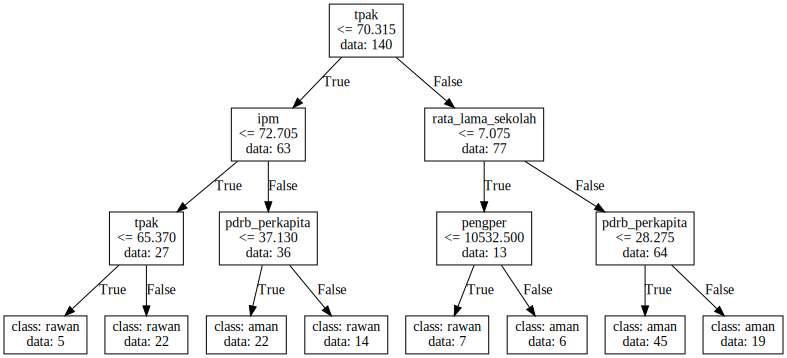

In [24]:


def visualize_tree_custom(model, feature_names, class_names):
    tree = model.tree_
    dot = Digraph()

    def add_node(node, parent=None, edge_label=""):
        n_samples = tree.n_node_samples[node]

        # cek apakah leaf
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            value = tree.value[node][0]
            class_id = value.argmax()

            label = f"class: {class_names[class_id]}\ndata: {n_samples}"
        else:
            feature = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]

            label = f"{feature}\n<= {threshold:.3f}\ndata: {n_samples}"

        node_id = str(node)
        dot.node(node_id, label, shape="box")

        if parent is not None:
            dot.edge(parent, node_id, label=edge_label)

        # rekursif kiri & kanan
        if tree.feature[node] != _tree.TREE_UNDEFINED:
            add_node(tree.children_left[node], node_id, "True")
            add_node(tree.children_right[node], node_id, "False")

    add_node(0)
    return dot

tree_graph = visualize_tree_custom(
    best_model,
    feature_names=X.columns.tolist(),
    class_names=["aman", "rawan"]
)

tree_graph